라이브러리 설치 및 임포트

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
# 필요한 라이브러리 설치
!pip install -q pandas numpy matplotlib seaborn scikit-learn lightgbm xgboost scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✓ 모든 라이브러리 설치 완료!")
print(f"Python 버전: {pd.__version__} (pandas), {np.__version__} (numpy)")

✓ 모든 라이브러리 설치 완료!
Python 버전: 2.2.2 (pandas), 2.0.2 (numpy)


Google Drive 마운트

In [ ]:
from google.colab import drive
import os

# Google Drive 마운트
drive.mount('/content/drive')

# 작업 디렉토리 확인
print("✓ Google Drive 마운트 완료")
print(f"현재 디렉토리: {os.getcwd()}")

# My Drive에 'IVF_Data' 폴더가 있다고 가정
DATA_PATH = '/content/drive/MyDrive/난임 임신 성공 예측 AI'

# 또는 이렇게 해도 됨:
# DATA_PATH = '/content/drive/MyDrive'  # 원하는 경로로 수정

print(f"\n데이터 경로: {DATA_PATH}")
print(f"경로 존재 여부: {os.path.exists(DATA_PATH)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive 마운트 완료
현재 디렉토리: /content

데이터 경로: /content/drive/MyDrive/난임 임신 성공 예측 AI
경로 존재 여부: False


데이터 업로드

In [ ]:
from google.colab import files

print("파일 업로드를 시작합니다...")
print("train.csv, test.csv, 데이터_명세.xlsx를 선택해주세요")

# 파일 업로드 (한번에 여러 파일 가능)
uploaded = files.upload()

print(f"\n업로드된 파일: {list(uploaded.keys())}")

# 현재 디렉토리에 파일이 저장됨
for filename in uploaded.keys():
    print(f"✓ {filename} 업로드 완료")

파일 업로드를 시작합니다...
train.csv, test.csv, 데이터_명세.xlsx를 선택해주세요


Saving 데이터 명세.xlsx to 데이터 명세 (3).xlsx
Saving test.csv to test (3).csv
Saving train.csv to train (3).csv

업로드된 파일: ['데이터 명세 (3).xlsx', 'test (3).csv', 'train (3).csv']
✓ 데이터 명세 (3).xlsx 업로드 완료
✓ test (3).csv 업로드 완료
✓ train (3).csv 업로드 완료


In [ ]:
train = pd.read_csv('train.csv')  # Cell 3에서 업로드한 경우
test = pd.read_csv('test.csv')
# 또는 Google Drive 경로 사용:
# train = pd.read_csv('/content/drive/MyDrive/IVF_Data/train.csv')
# test = pd.read_csv('/content/drive/MyDrive/IVF_Data/test.csv')

In [ ]:
print("✓ 데이터 로드 완료!")
print(f"\n훈련 데이터: {train.shape}")
print(f"테스트 데이터: {test.shape}")

print(f"\n훈련 데이터 첫 5행:")
print(train.head())

✓ 데이터 로드 완료!

훈련 데이터: (256351, 69)
테스트 데이터: (90067, 68)

훈련 데이터 첫 5행:
             ID 시술 시기 코드 시술 당시 나이  임신 시도 또는 마지막 임신 경과 연수 시술 유형 특정 시술 유형  \
0  TRAIN_000000   TRZKPL  만18-34세                    NaN   IVF     ICSI   
1  TRAIN_000001   TRYBLT  만45-50세                    NaN   IVF     ICSI   
2  TRAIN_000002   TRVNRY  만18-34세                    NaN   IVF      IVF   
3  TRAIN_000003   TRJXFG  만35-37세                    NaN   IVF     ICSI   
4  TRAIN_000004   TRVNRY  만18-34세                    NaN   IVF     ICSI   

   배란 자극 여부    배란 유도 유형  단일 배아 이식 여부  착상 전 유전 검사 사용 여부  ...  기증 배아 사용 여부  \
0         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
1         0      알 수 없음          0.0               NaN  ...          0.0   
2         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
3         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
4         1  기록되지 않은 시행          0.0               NaN  ...          0.0   

   대리모 여부  PGD 시술 여부  

EDA (탐색적 데이터 분석)

📊 EDA - 탐색적 데이터 분석 시작

【 타겟 변수 분석 】
임신 실패 (0): 190,123 (74.17%)
임신 성공 (1): 66,228 (25.83%)
클래스 불균형: 2.87:1


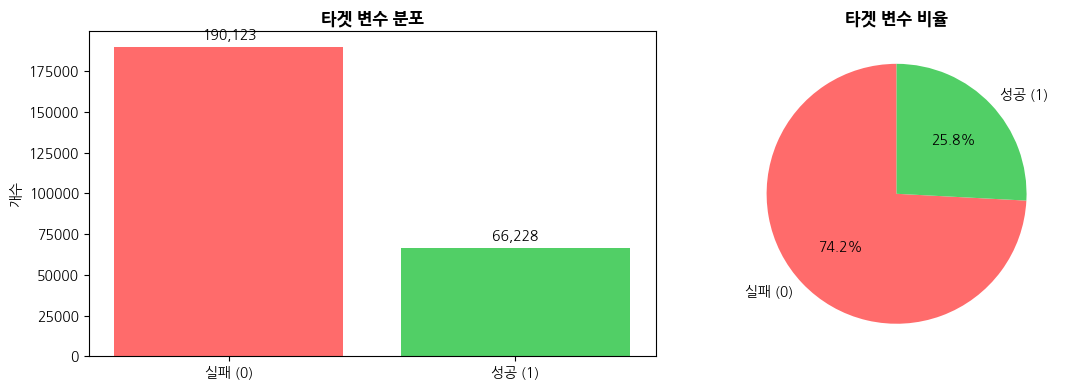


【 결측값 분석 】
                    열  결측 개수  결측률 (%)
            난자 해동 경과일 254915    99.44
            PGS 시술 여부 254422    99.25
            PGD 시술 여부 254172    99.15
     착상 전 유전 검사 사용 여부 253633    98.94
임신 시도 또는 마지막 임신 경과 연수 246981    96.34
            배아 해동 경과일 215982    84.25
            난자 채취 경과일  57488    22.43
            난자 혼합 경과일  53735    20.96
            배아 이식 경과일  43566    16.99
      미세주입 후 저장된 배아 수   6291     2.45
             해동된 배아 수   6291     2.45
             저장된 배아 수   6291     2.45
         미세주입 배아 이식 수   6291     2.45
               대리모 여부   6291     2.45
          단일 배아 이식 여부   6291     2.45


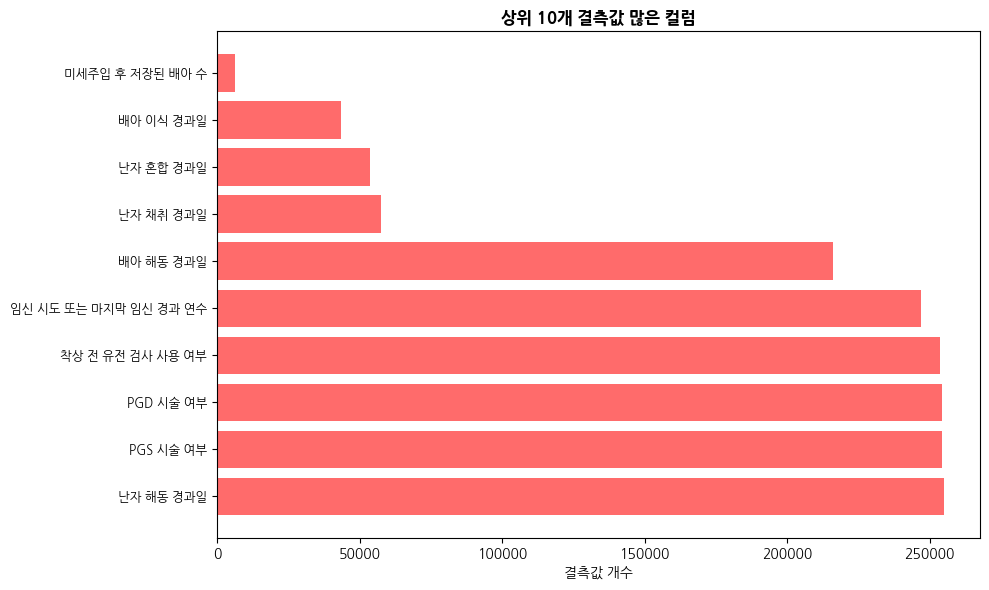


【 변수 타입 분류 】
수치형 변수: 47개
범주형 변수: 20개

【 수치형 변수 통계 】
       임신 시도 또는 마지막 임신 경과 연수   배란 자극 여부  단일 배아 이식 여부  착상 전 유전 검사 사용 여부  \
count                9370.00  256351.00    250060.00            2718.0   
mean                    9.27       0.77         0.23               1.0   
std                     3.55       0.42         0.42               0.0   
min                     0.00       0.00         0.00               1.0   
25%                     7.00       1.00         0.00               1.0   
50%                     9.00       1.00         0.00               1.0   
75%                    11.00       1.00         0.00               1.0   
max                    20.00       1.00         1.00               1.0   

       착상 전 유전 진단 사용 여부  남성 주 불임 원인  남성 부 불임 원인  여성 주 불임 원인  여성 부 불임 원인  \
count         250060.00   256351.00   256351.00   256351.00   256351.00   
mean               0.01        0.03        0.01        0.03        0.01   
std                0.11        0.17        0.11        

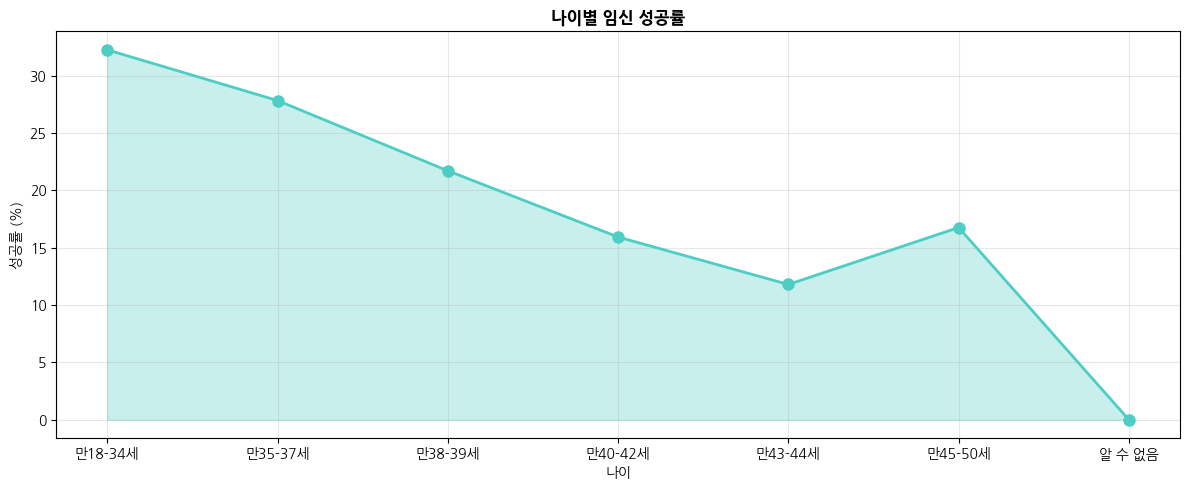


✓ EDA 분석 완료!
🔧 데이터 전처리 시작

[STEP 1] 훈련 데이터 통계 추출 중...
✓ 수치형 통계: 47개 추출
✓ 범주형 통계: 20개 추출

[STEP 2] 결측값 처리 완료
훈련 데이터 결측값: 0
테스트 데이터 결측값: 0

[STEP 3] 로그 변환 중...
✓ 4개 변수 로그 변환 완료

[STEP 4] 파생 변수 생성 중...
✓ 파생 변수 생성 완료
  특성 개수: 67

[STEP 5] 범주형 변수 인코딩 중...
✓ 20개 범주형 변수 인코딩 완료

✓ 전처리 완료!

【 최종 데이터 크기 】
훈련 데이터: (256351, 67)
테스트 데이터: (90067, 67)
타겟 데이터: (256351,)

【 데이터 타입 】
int64: 38
float64: 29

【 결측값 】
훈련: 0
테스트: 0


In [ ]:
print("=" * 80)
print("📊 EDA - 탐색적 데이터 분석 시작")
print("=" * 80)

# 타겟 변수 추출
y_train = train['임신 성공 여부'].copy()
X_train = train.drop(['ID', '임신 성공 여부'], axis=1)
X_test = test.drop('ID', axis=1)

# ============================================================================
# 1. 타겟 변수 분석
# ============================================================================

print("\n【 타겟 변수 분석 】")
print(f"임신 실패 (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"임신 성공 (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"클래스 불균형: {(y_train==0).sum() / (y_train==1).sum():.2f}:1")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y_train.value_counts()
axes[0].bar(['실패 (0)', '성공 (1)'], counts.values, color=['#FF6B6B', '#51CF66'])
axes[0].set_title('타겟 변수 분포', fontsize=12, fontweight='bold')
axes[0].set_ylabel('개수')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center')

axes[1].pie(counts.values, labels=['실패 (0)', '성공 (1)'], autopct='%1.1f%%',
            colors=['#FF6B6B', '#51CF66'], startangle=90)
axes[1].set_title('타겟 변수 비율', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# 2. 결측값 분석
# ============================================================================

print("\n【 결측값 분석 】")
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_train / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    '열': missing_train.index,
    '결측 개수': missing_train.values,
    '결측률 (%)': missing_pct.values
})
print(missing_df[missing_df['결측 개수'] > 0].head(15).to_string(index=False))

# 시각화
missing_high = missing_train[missing_train > 0].head(10)
plt.figure(figsize=(10, 6))
plt.barh(range(len(missing_high)), missing_high.values, color='#FF6B6B')
plt.yticks(range(len(missing_high)), missing_high.index, fontsize=9)
plt.xlabel('결측값 개수')
plt.title('상위 10개 결측값 많은 컬럼', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 3. 변수 타입 분류
# ============================================================================

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"\n【 변수 타입 분류 】")
print(f"수치형 변수: {len(numeric_cols)}개")
print(f"범주형 변수: {len(categorical_cols)}개")

# ============================================================================
# 4. 수치형 변수 통계
# ============================================================================

print(f"\n【 수치형 변수 통계 】")
print(X_train[numeric_cols].describe().round(2))

# ============================================================================
# 5. 나이별 성공률 (가장 중요한 변수)
# ============================================================================

print(f"\n【 나이별 임신 성공률 】")
if '시술 당시 나이' in X_train.columns:
    age_success = train.groupby('시술 당시 나이')['임신 성공 여부'].agg(['count', 'sum', 'mean'])
    age_success.columns = ['총계', '성공', '성공률']
    age_success = age_success[age_success['총계'] >= 10]
    print(age_success)

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(age_success.index, age_success['성공률'] * 100, marker='o',
             linewidth=2, markersize=8, color='#4ECDC4')
    plt.fill_between(age_success.index, age_success['성공률'] * 100, alpha=0.3, color='#4ECDC4')
    plt.xlabel('나이')
    plt.ylabel('성공률 (%)')
    plt.title('나이별 임신 성공률', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n✓ EDA 분석 완료!")


# 데이터 전처리 (핵심)
print("=" * 80)
print("🔧 데이터 전처리 시작")
print("=" * 80)

# ============================================================================
# STEP 1: 훈련 통계 추출 (Data Leakage 규칙 준수)
# ============================================================================

print("\n[STEP 1] 훈련 데이터 통계 추출 중...")

# 수치형 변수: 중앙값
numeric_stats = {}
for col in numeric_cols:
    numeric_stats[col] = X_train[col].median()

# 범주형 변수: 최빈값
categorical_stats = {}
for col in categorical_cols:
    if len(X_train[col].mode()) > 0:
        categorical_stats[col] = X_train[col].mode()[0]
    else:
        categorical_stats[col] = '알 수 없음'

print(f"✓ 수치형 통계: {len(numeric_stats)}개 추출")
print(f"✓ 범주형 통계: {len(categorical_stats)}개 추출")

# ============================================================================
# STEP 2: 결측값 처리 함수
# ============================================================================

def preprocess_data(df, numeric_stats, categorical_stats):
    """
    ✅ Data Leakage 규칙 준수:
       - 훈련 데이터의 통계 정보만 사용
       - 테스트 데이터 통계는 미사용
    """
    df = df.copy()

    # 범주형 변수 결측값 처리
    for col in categorical_stats.keys():
        if col in df.columns:
            df[col] = df[col].fillna(categorical_stats[col])

    # 수치형 변수 결측값 처리
    for col in numeric_stats.keys():
        if col in df.columns:
            df[col] = df[col].fillna(numeric_stats[col])

    return df

# 적용
X_train = preprocess_data(X_train, numeric_stats, categorical_stats)
X_test = preprocess_data(X_test, numeric_stats, categorical_stats)

print("\n[STEP 2] 결측값 처리 완료")
print(f"훈련 데이터 결측값: {X_train.isnull().sum().sum()}")
print(f"테스트 데이터 결측값: {X_test.isnull().sum().sum()}")

# ============================================================================
# STEP 3: 로그 변환
# ============================================================================

print("\n[STEP 3] 로그 변환 중...")

high_skew_cols = [
    '저장된_배아_수',
    '해동된_배아_수',
    '저장된_신선_난자_수',
    '기증자_정자와_혼합된_난자_수'
]

for col in high_skew_cols:
    if col in X_train.columns:
        X_train[f'{col}_log'] = np.log1p(X_train[col])
        X_test[f'{col}_log'] = np.log1p(X_test[col])

print(f"✓ {len(high_skew_cols)}개 변수 로그 변환 완료")

# ============================================================================
# STEP 4: 파생 변수 생성
# ============================================================================

print("\n[STEP 4] 파생 변수 생성 중...")

def create_derived_features(df):
    """각 샘플 독립적인 연산으로 Data Leakage 방지"""
    df = df.copy()

    if '총_임신_횟수' in df.columns and '총_시술_횟수' in df.columns:
        df['과거_성공_비율'] = df['총_임신_횟수'] / (df['총_시술_횟수'] + 1)

    if '총_출산_횟수' in df.columns and '총_시술_횟수' in df.columns:
        df['과거_출산_비율'] = df['총_출산_횟수'] / (df['총_시술_횟수'] + 1)

    if '총_생성_배아_수' in df.columns and '혼합된_난자_수' in df.columns:
        df['배아_생성_효율'] = df['총_생성_배아_수'] / (df['혼합된_난자_수'] + 1)

    if '이식된_배아_수' in df.columns and '총_생성_배아_수' in df.columns:
        df['배아_이식_효율'] = df['이식된_배아_수'] / (df['총_생성_배아_수'] + 1)

    if '저장된_배아_수' in df.columns and '총_생성_배아_수' in df.columns:
        df['배아_저장률'] = df['저장된_배아_수'] / (df['총_생성_배아_수'] + 1)

    df = df.fillna(0)
    return df

X_train = create_derived_features(X_train)
X_test = create_derived_features(X_test)

print(f"✓ 파생 변수 생성 완료")
print(f"  특성 개수: {X_train.shape[1]}")

# ============================================================================
# STEP 5: 범주형 변수 인코딩
# ============================================================================

print("\n[STEP 5] 범주형 변수 인코딩 중...")

# 현재 범주형 변수 찾기
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

for col in categorical_features:
    # ✅ 훈련 데이터의 범주만 사용 (Data Leakage 방지)
    unique_categories = sorted(X_train[col].unique())
    category_mapping = {cat: idx for idx, cat in enumerate(unique_categories)}

    X_train[col] = X_train[col].map(category_mapping)
    X_test[col] = X_test[col].map(category_mapping).fillna(-1).astype(int)

print(f"✓ {len(categorical_features)}개 범주형 변수 인코딩 완료")

# ============================================================================
# STEP 6: 최종 확인
# ============================================================================

print("\n" + "=" * 80)
print("✓ 전처리 완료!")
print("=" * 80)

print(f"\n【 최종 데이터 크기 】")
print(f"훈련 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print(f"타겟 데이터: {y_train.shape}")

print(f"\n【 데이터 타입 】")
print(f"int64: {(X_train.dtypes == 'int64').sum()}")
print(f"float64: {(X_train.dtypes == 'float64').sum()}")

print(f"\n【 결측값 】")
print(f"훈련: {X_train.isnull().sum().sum()}")
print(f"테스트: {X_test.isnull().sum().sum()}")